# Logistic Regression Assignment – Corrected Version

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
lr_data = pd.read_csv("diabetes.csv")

lr_data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Basic info
lr_data.shape

(768, 9)

In [3]:
lr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
lr_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Check missing values
lr_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

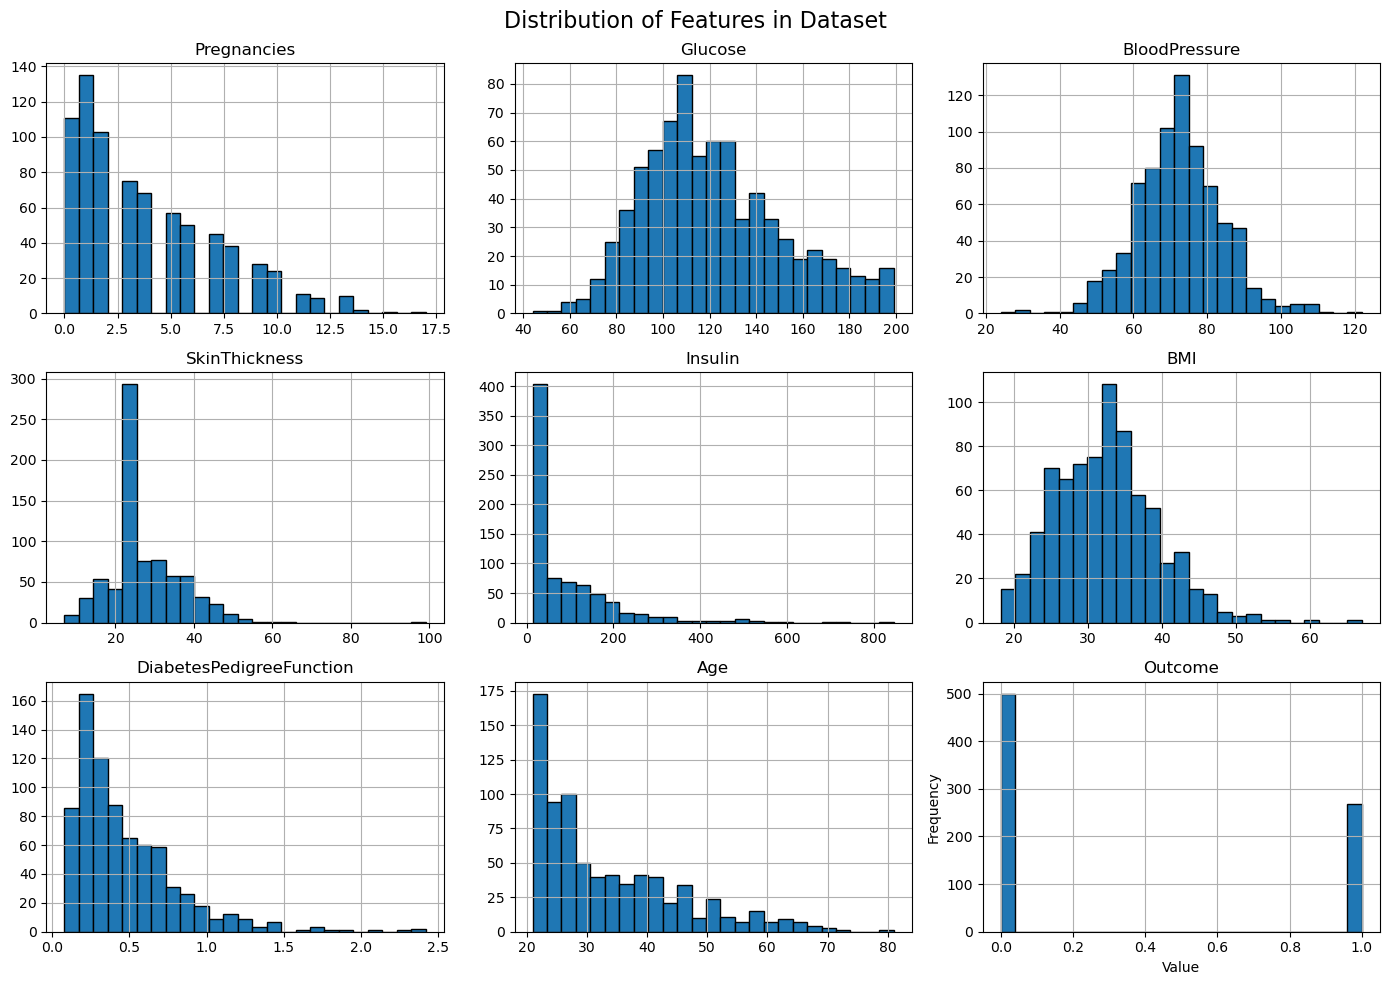

In [23]:
# Histograms

lr_data.hist(figsize=(14, 10), bins=25, edgecolor='black')

plt.suptitle("Distribution of Features in Dataset", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


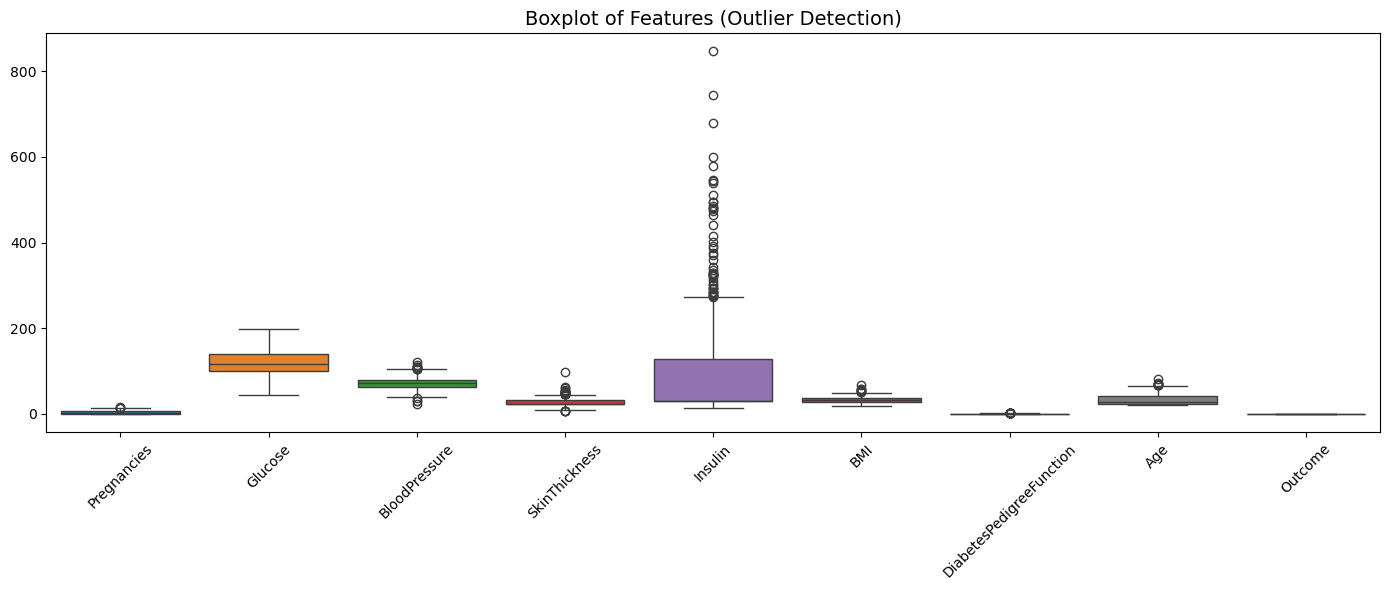

In [24]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=lr_data)
plt.title("Boxplot of Features (Outlier Detection)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

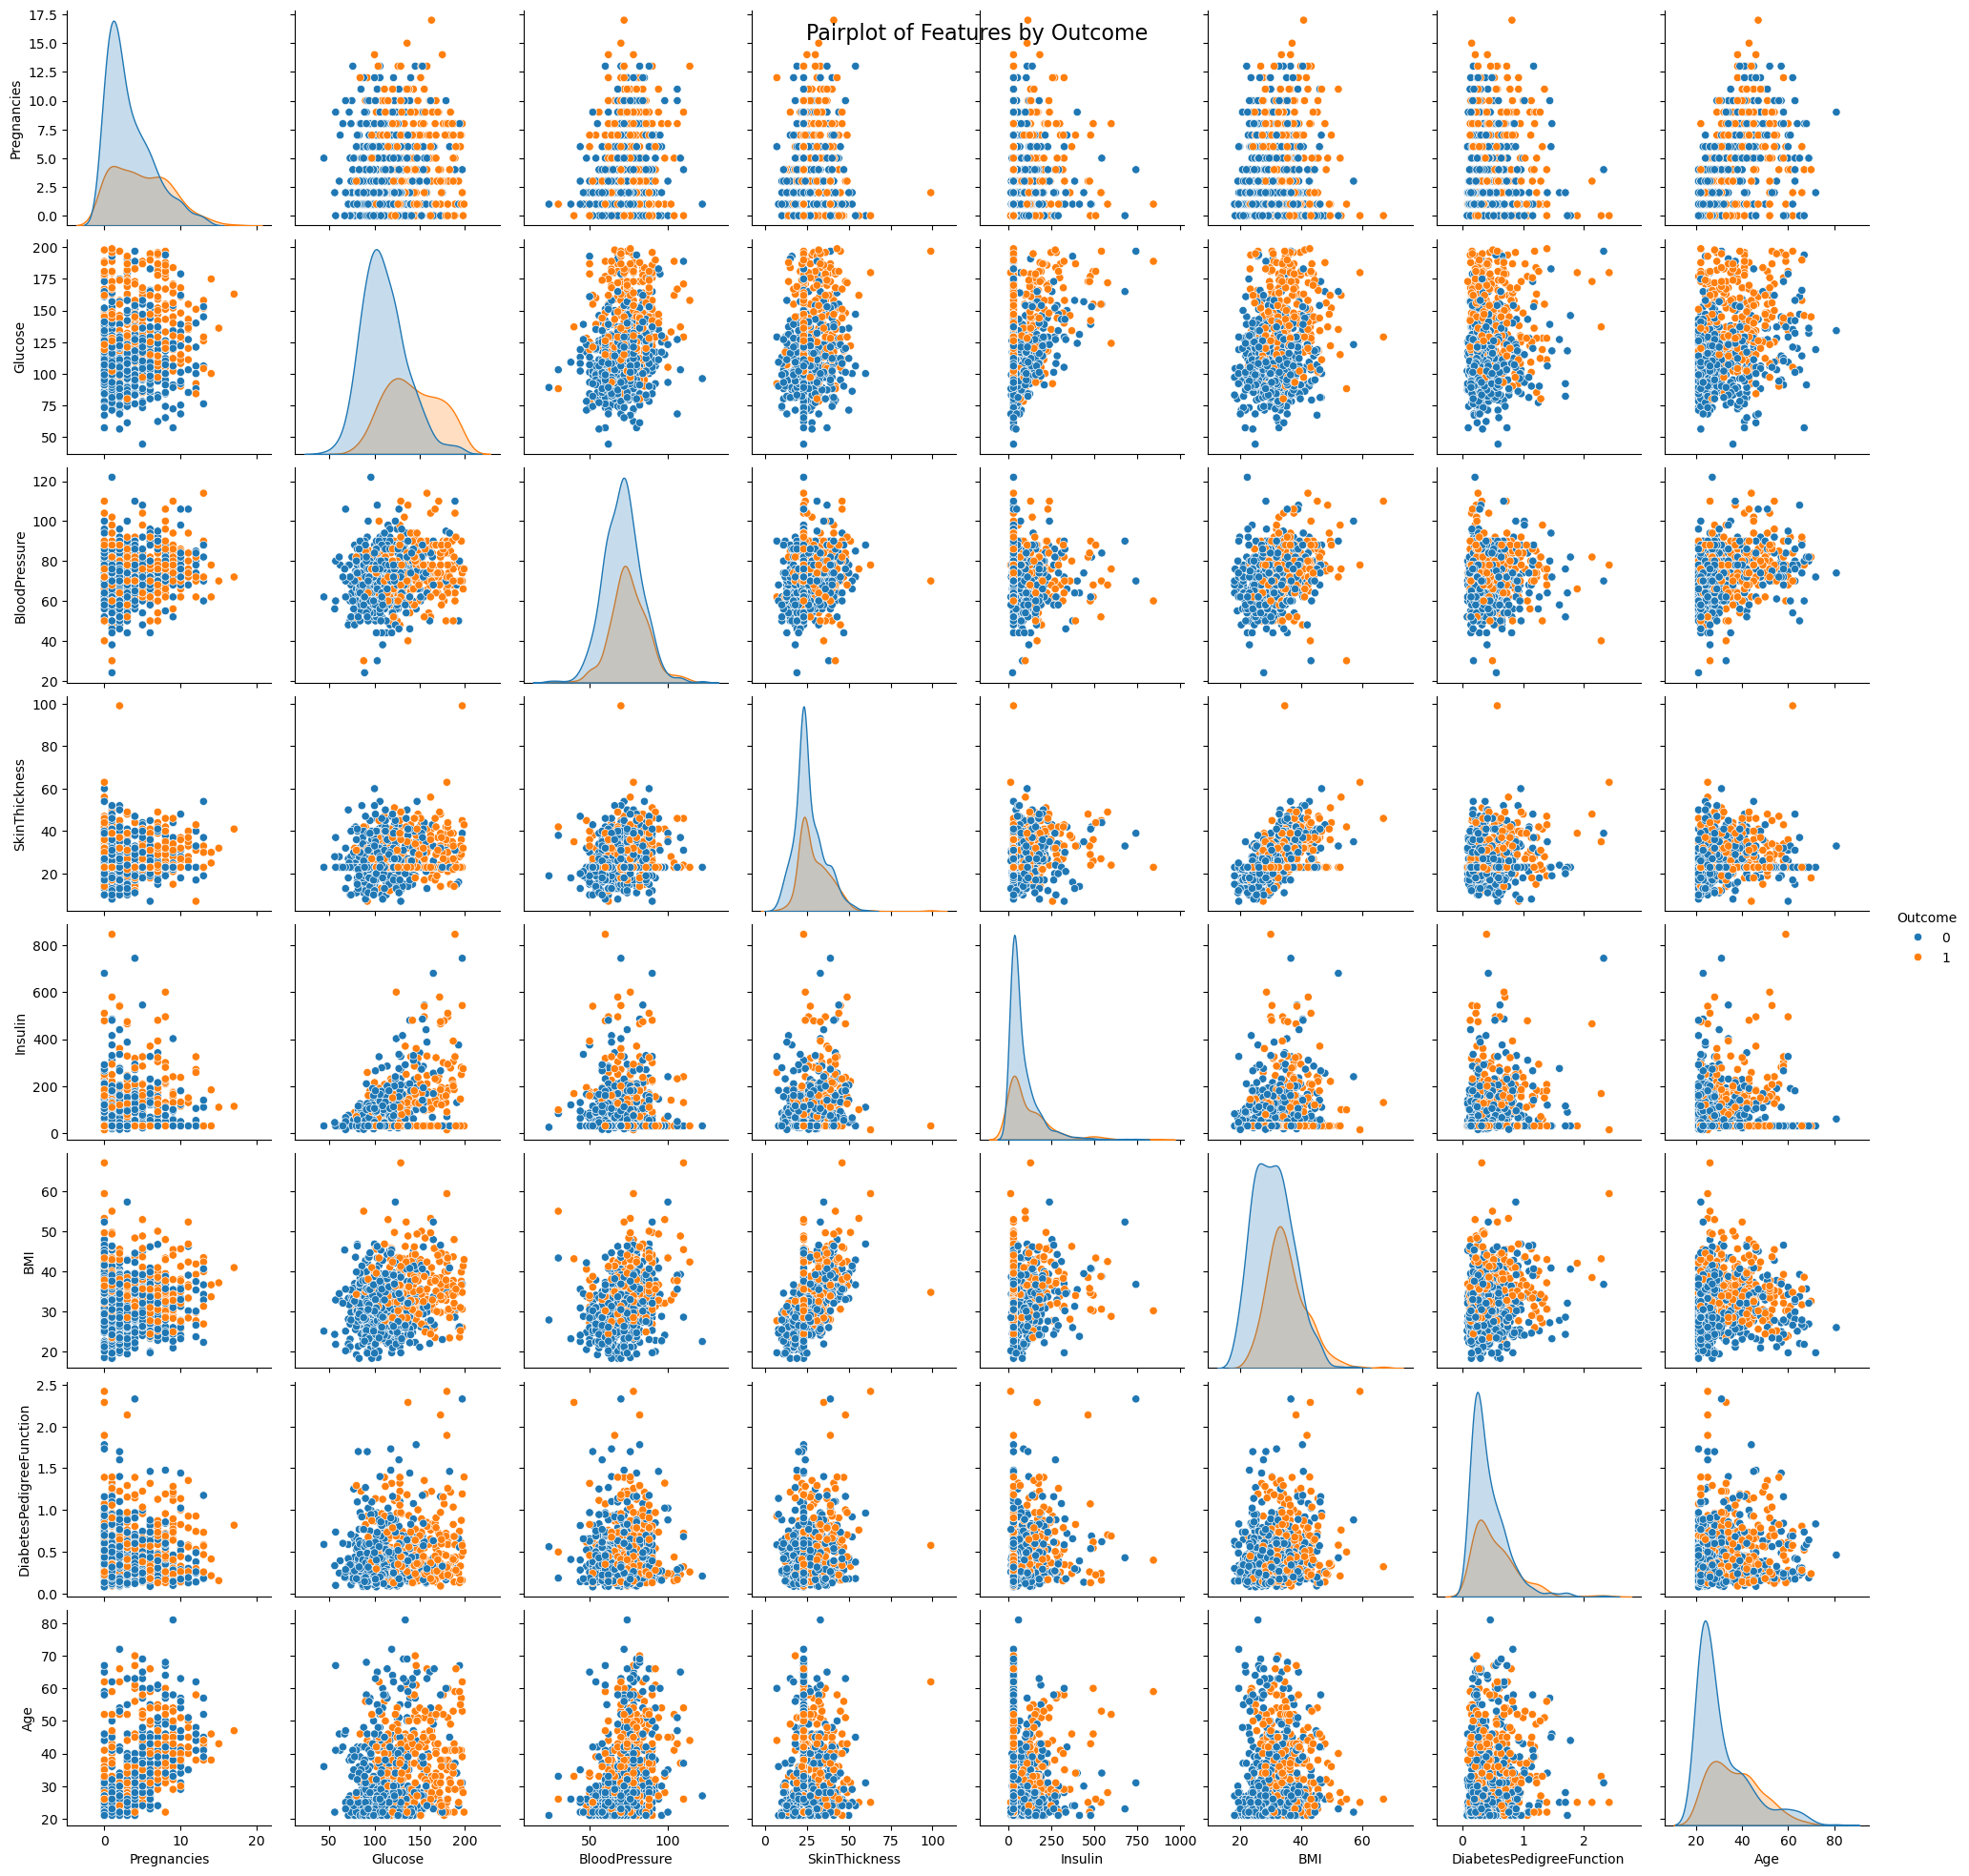

In [27]:
sns.pairplot(lr_data,hue="Outcome", diag_kind="kde")

plt.suptitle("Pairplot of Features by Outcome", fontsize=16)
plt.show()

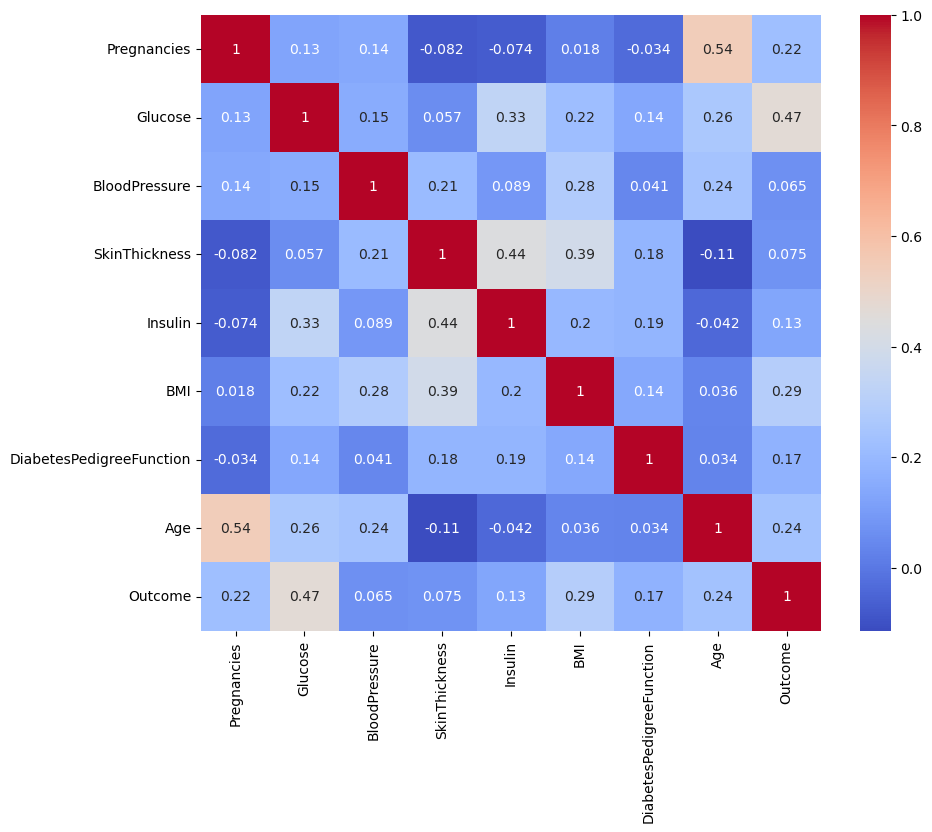

In [9]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(lr_data.corr(), annot=True, cmap="coolwarm")
plt.show()

## Data Preprocessing Explanation

Some medical features like Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI contained zero values, which are not medically valid and treated as missing values. These values were replaced using the median of each respective feature to avoid skewing the data. Since the dataset contains only numerical features, no categorical encoding was required.

In [10]:
# Replace 0 with NaN in specific columns
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    lr_data[col] = lr_data[col].replace(0, lr_data[col].median())

lr_data.fillna(lr_data.median(), inplace=True)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = lr_data.drop("Outcome", axis=1)
y = lr_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.7662337662337663
Precision: 0.6792452830188679
Recall: 0.6545454545454545
F1 Score: 0.6666666666666666
ROC-AUC: 0.8196510560146923


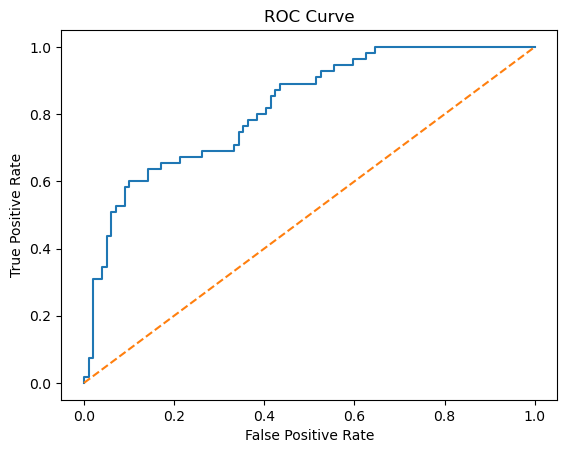

In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance


,Feature,Coefficient
1,Glucose,1.138214
5,BMI,0.718367
7,Age,0.378817
0,Pregnancies,0.218415
6,DiabetesPedigreeFunction,0.216745
3,SkinThickness,0.049443
2,BloodPressure,-0.165564
4,Insulin,-0.224917



### Explanation:
- Positive coefficients increase the probability of diabetes.
- Negative coefficients decrease the probability.
- Features like **Glucose** and **BMI** usually have strong positive impact.


In [16]:
import joblib
joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [17]:
import pickle
pickle.dump(model, open("logistic_model.pkl", "wb"))


In [18]:
model = pickle.load(open("logistic_model.pkl", "rb"))


## 6. Deployment with Streamlit

The trained logistic regression model was deployed using Streamlit.
A Streamlit application was created to load the saved model, take user
inputs, and display prediction results.

The application was deployed on Streamlit Community Cloud using a GitHub
repository. The deployed app is working correctly and produces predictions
for user-provided inputs.

Deployment link:
https://your-streamlit-app-link


### Streamlit App Screenshot

![Streamlit App](http://localhost:8889/files/MLR/resubmit/Streamlit%20ML%20project/app.png?_xsrf=2%7C9df5aef1%7C23cddba7045fa5a6fe7a10fd66de398c%7C1767079163)


## Interview Questions

#### 1. What is the difference between precision and recall?


Precision and recall are evaluation measures used in binary classification. Precision refers to how accurate the positive predictions of a model are, meaning it shows how many of the cases predicted as positive are actually correct. It focuses on avoiding false positive results. Recall refers to how well a model identifies all actual positive cases, meaning it shows how many true positive cases are successfully detected. It focuses on avoiding missed positive cases. Both measures are important because improving one can sometimes reduce the other.

#### 2. What is cross-validation, and why is it important in binary classification?



Cross-validation is a method used to evaluate a model by dividing the dataset into several parts and training and testing the model multiple times. Each part of the data is used for testing at least once. This helps in checking whether the model performs well not only on training data but also on new and unseen data. In binary classification, cross-validation is important because it reduces overfitting, gives a more reliable performance estimate, and ensures balanced evaluation when the data contains unequal classes.